In [1]:
%load_ext autoreload
%autoreload 2   

import jax.numpy as jnp

## same imports as examples_basic.py
import numpy as np
import matplotlib.pyplot as plt

from evoscape.landscapes import Landscape
from evoscape.modules import Node, UnstableNode, Center, NegCenter
from evoscape.landscape_visuals import *
from evoscape.morphogen_regimes import mr_const, mr_sigmoid, mr_piecewise

from evoscape.experiment import Experiment

plt.style.use('default')
plt.rcParams.update({'figure.dpi': 100})
plt.rcParams.update({'font.size': 15})  

Landscape with modules:
Node: x=-1.5; y=0.0; a=[1.5,2.0]; s=[1.0,0.6],
Node: x=1.5; y=0.0; a=[2.,2.]; s=[0.5,1.2],
Node: x=0.0; y=1.0; a=[1.3,1.4]; s=[0.8,0.5]


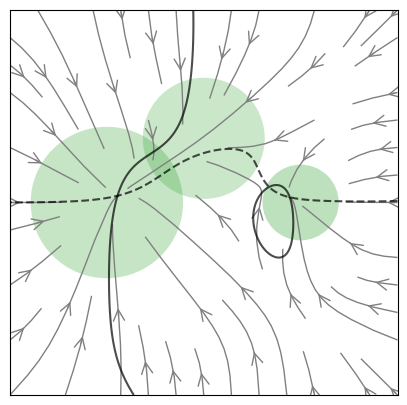

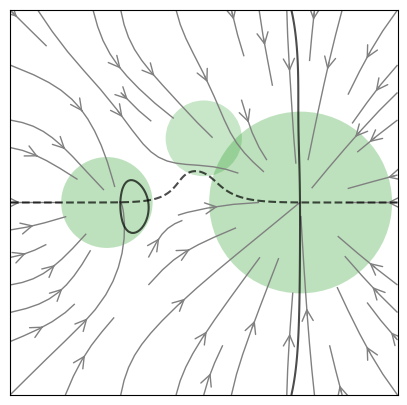

In [2]:

# Landscape with one regime + simple visualization
M1 = Node(x=-1.5, y=0., a=(1.5, 2.), s=(1., 0.6))
M2 = Node(x=1.5, y=0., a=(2., 2.), s=(0.5, 1.2))
M3 = Node(x=0., y=1., a=(1.3, 1.4), s=(0.8, 0.5))

module_list = [M1, M2, M3]

landscape = Landscape(module_list, A0 = 0.005, regime=mr_piecewise, n_regimes=2)
print(landscape)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(landscape, xx, yy, regime=0, color_scheme='fp_types')
fig = visualize_landscape(landscape, xx, yy, regime=1, color_scheme='fp_types')

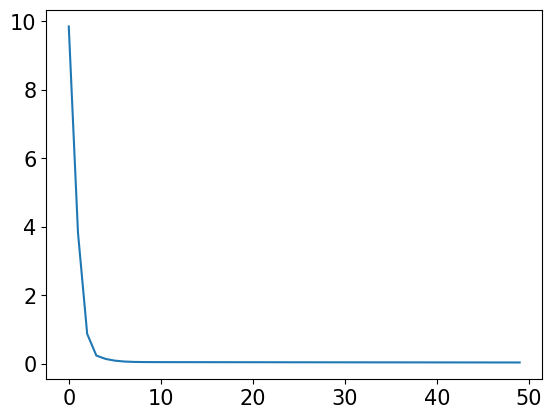

In [3]:
exp = Experiment(landscape)

q_flat = np.random.randn(2,5)

exp.set_initial_conditions(q_flat)
exp.set_regime("piecewise", t_list=[0.5, 50.])
exp.set_simulation(t0=0.0, tf=5.0, nt=100, ndt=10, noise=0.1)

def fitness(traj, states):
    final_coordinates = traj[:, :, -1]
    return jnp.sum(final_coordinates ** 2)

fitness_vals = exp.optimize(fitness, steps=50, lr=0.05)
plt.plot(fitness_vals)

Landscape with modules:
Node: x=-0.9491558; y=-0.08393363; a=[1.4994103,1.9233904]; s=[0.99955970,0.78514177],
Node: x=0.38063166; y=-0.29097435; a=[1.9999963,2.1478338]; s=[0.49991617,1.64427841],
Node: x=0.01511117; y=0.78539926; a=[1.3000768,1.3820661]; s=[0.80049521,0.78031737]


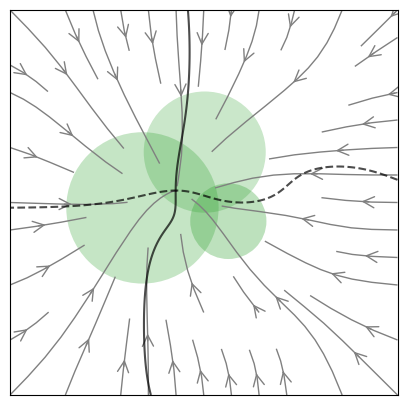

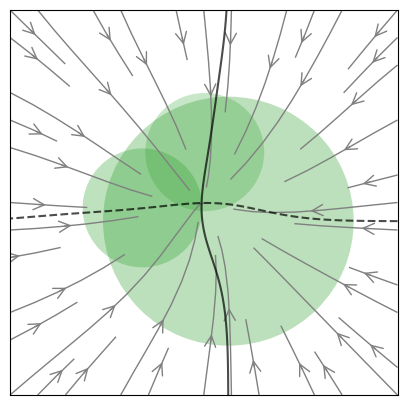

In [4]:
l = exp.get_landscape()


print(l)

L = 3.
npoints = 201
q = np.linspace(-L, L, npoints)
xx, yy = np.meshgrid(q, q, indexing='xy')

fig = visualize_landscape(l, xx, yy, regime=0, color_scheme='fp_types')
fig = visualize_landscape(l, xx, yy, regime=1, color_scheme='fp_types')

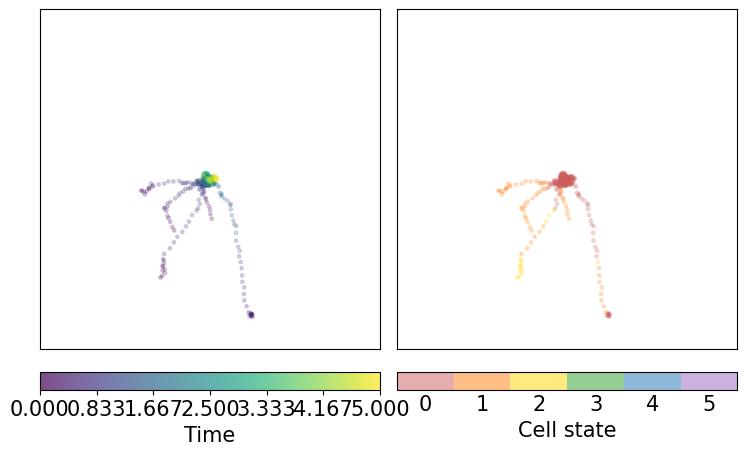

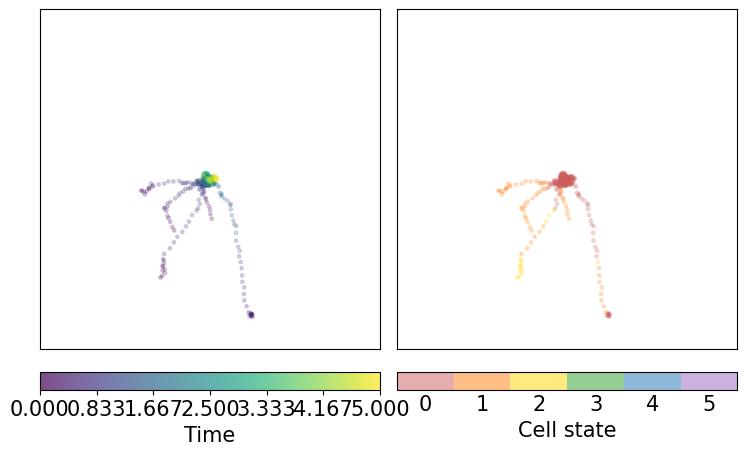

In [5]:
traj, states, t0, tf, nt = exp.get_trajectory()

plot_traj(traj, states, t0, tf, nt, L)